In [1]:
import os
import scanpy as sc
import numpy as np
import pandas as pd
import scipy.sparse as sp
import matplotlib.pyplot as plt
import json
from scipy.stats import mannwhitneyu
import seaborn as sns



In [2]:
adata = sc.read_h5ad('CC_GMM_groups_adata.h5ad')

In [3]:
# 1. hk_genes
hk_genes =["Actb","Rplp0","Hsp90ab1" ,"Ubc", "Eef1a1","Ppia","Ywhaz","Gapdh"]
samples_to_remove = ['Label_NC_1', 'Label_NC_2']
adata_cancer = adata[~adata.obs['orig.ident'].isin(samples_to_remove)].copy()
valid_hk = [g for g in hk_genes if g in adata_cancer.var_names]

hk_total = np.asarray(adata_cancer[:, valid_hk].layers['total'].mean(axis=1)).flatten()
hk_new = np.asarray(adata_cancer[:, valid_hk].layers['new'].mean(axis=1)).flatten()
adata_cancer.layers['alpha_fil0'] = np.nan_to_num(adata_cancer.layers['alpha'], nan=0.0)
hk_alpha = np.asarray(adata_cancer[:, valid_hk].layers['alpha_fil0'].mean(axis=1)).flatten()

adata_cancer.obs['HK_nCount_mean'] = hk_total
adata_cancer.obs['HK_new_mean'] = hk_new
adata_cancer.obs['HK_alpha_mean'] = hk_alpha

# 2. filter
valid_mask = (adata_cancer.obs['HK_nCount_mean'] > 0) & \
             (adata_cancer.obs['HK_alpha_mean'] > 0) & \
             (adata_cancer.obs['HK_new_mean'] > 0)

adata_valid = adata_cancer[valid_mask].copy()
print(f"valid cells: {adata_valid.n_obs} (del {adata_cancer.n_obs - adata_valid.n_obs} cells)")

valid cells: 15178 (del 656 cells)


In [4]:
# Function 1: Compute Pathway Enrichment Score for Single Cells

def calculate_pathway_score(adata, json_path, pathway_key, score_name=None):

    if score_name is None:
        score_name = f"{pathway_key}_Score"
        
    # 1. Extract pathway genes from JSON
    with open(json_path, 'r', encoding='utf-8') as f:
        msigdb_data = json.load(f)
    pathway_genes = msigdb_data[pathway_key]["geneSymbols"]
    valid_genes = [g for g in pathway_genes if g in adata.var_names]
    
    if len(valid_genes) == 0:
        print(f"Warning: No matching genes found for pathway {pathway_key} in adata!")
        return adata

    # Extract raw alpha matrix for valid genes
    pathway_alpha = adata[:, valid_genes].layers['alpha']
    if sp.issparse(pathway_alpha):
        pathway_alpha = pathway_alpha.toarray()

    # Build a DataFrame grouped by time points
    df_cells = pd.DataFrame(pathway_alpha, columns=valid_genes)
    df_cells['time'] = adata.obs['time'].values
    df_time_avg = df_cells.groupby('time').mean()
    desired_order = ["D3", "D5", "D7", "D9", "D11", "D20"]
    df_time_avg = df_time_avg.loc[[t for t in desired_order if t in df_time_avg.index]]
    
    global_median = np.median(df_time_avg.values)
    gene_max_across_time = df_time_avg.max(axis=0)
    keep_genes_mask = gene_max_across_time >= global_median
    df_time_avg_filtered = df_time_avg.loc[:, keep_genes_mask]

    # Final sorting and precise slicing of Top 5 genes
    if df_time_avg_filtered.shape[1] > 0:
        final_gene_means = df_time_avg_filtered.mean(axis=0)
        final_gene_means_sorted = final_gene_means.sort_values(ascending=False)
        top5_genes_aligned = final_gene_means_sorted.head(5).index.tolist()
        top5_values_aligned = final_gene_means_sorted.head(5).values
    else:
        top5_genes_aligned = []
        top5_values_aligned = []

    print(f"Pathway: {pathway_key}")
    print(f"Top 5 Core Driving Genes:")
    for r, (g, val) in enumerate(zip(top5_genes_aligned, top5_values_aligned), 1):
        print(f"      Rank {r} : {g} ")

    if len(top5_genes_aligned) == 0:
        print("Error: No genes passed the filtering thresholds. Cannot compute score.")
        return adata

    # Extract alpha for Top 5 genes to compute cell scores
    top5_alpha_fil0 = adata[:, top5_genes_aligned].layers['alpha_fil0']
    if sp.issparse(top5_alpha_fil0):
        top5_alpha_fil0 = top5_alpha_fil0.toarray()

    # Save
    mean_col_name = f"{pathway_key}_Top5_Mean"
    adata.obs[mean_col_name] = np.mean(top5_alpha_fil0, axis=1)
    adata.obs[score_name] = adata.obs[mean_col_name] / adata.obs['HK_alpha_mean']
    
    return adata

In [5]:
# Function 2: Generate Faceted Bar Plots

def plot_pathway_enrichment(adata, score_col, target_cells, time_order, output_pdf, plot_title):

    # Extract data for plotting
    plot_df = adata.obs[adata.obs['CCtype'].isin(target_cells)].copy()
    plot_df = plot_df.dropna(subset=['time', 'Kinetics_State', score_col])

    # Draw faceted bar plots
    g = sns.catplot(
        data=plot_df, x='time', y=score_col, 
        hue='Kinetics_State', col='CCtype', 
        kind='bar', palette={'High': '#e74c3c', 'Low': '#3498db'},
        order=time_order, col_order=target_cells, hue_order=['High', 'Low'],
        errorbar='se', capsize=0.1, errwidth=1, errcolor='black', 
        sharey=True, height=4, aspect=1.2, edgecolor='black', linewidth=0
    )

    y_max_overall = plot_df[score_col].quantile(0.95)
    fixed_star_y = y_max_overall * 0.8

    for ax, cell_type in zip(g.axes.flat, target_cells):
        ax.set_title(f"{cell_type}", fontsize=13, fontweight='bold', pad=10)
        
        for i, t in enumerate(time_order):
            subset = plot_df[(plot_df['CCtype'] == cell_type) & (plot_df['time'] == t)]
            high = subset[subset['Kinetics_State'] == 'High'][score_col]
            low = subset[subset['Kinetics_State'] == 'Low'][score_col]
            
            # Run test
            if len(high) > 3 and len(low) > 3:
                _, p = mannwhitneyu(high, low, alternative='two-sided')
                star = '***' if p < 0.001 else '**' if p < 0.01 else '*' if p < 0.05 else 'ns'
                
                ax.text(i, fixed_star_y, star, ha='center', va='bottom', 
                        fontsize=14, fontweight='bold', color='black')

    # Styling and Axis Customization
    g.set_axis_labels("Time (Days)", "Enrichment Score\n(Top 5 / HKGs)", fontweight='bold')
    g.despine(left=False)
    g.set(yticks=[0.5, 1.0])

    plt.subplots_adjust(top=0.85)
    g.figure.suptitle(plot_title, fontsize=16, fontweight='bold')
    sns.move_legend(g, "upper right", bbox_to_anchor=(1.05, 0.9), title='Kinetics State', frameon=False)
    
    # Save and render
    plt.savefig(output_pdf, format='pdf', bbox_inches='tight', dpi=300)
    plt.show()

Pathway: HALLMARK_ESTROGEN_RESPONSE_EARLY
Top 5 Core Driving Genes:
      Rank 1 : Fos 
      Rank 2 : Klf4 
      Rank 3 : Slc7a5 
      Rank 4 : Bhlhe40 
      Rank 5 : Tiparp 


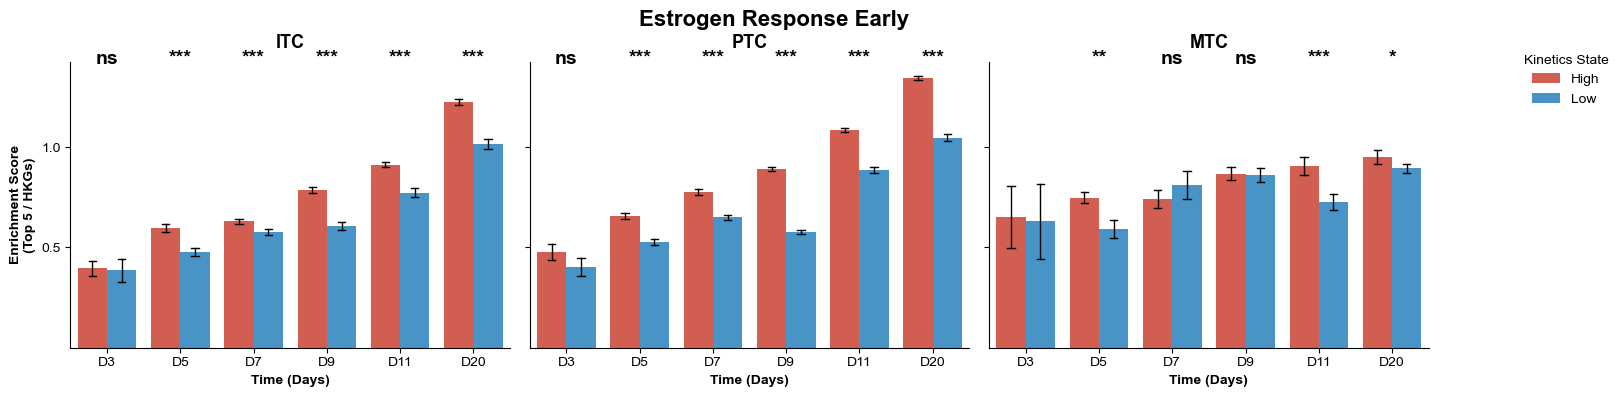

In [ ]:
# pathway 1
json_file = 'HALLMARK_ESTROGEN_RESPONSE_EARLY.v2026.1.Mm.json'
pathway = "HALLMARK_ESTROGEN_RESPONSE_EARLY"
cells = ['ITC', 'PTC', 'MTC']
times = ['D3', 'D5', 'D7', 'D9', 'D11', 'D20']

adata_valid = calculate_pathway_score(
    adata=adata_valid, 
    json_path=json_file, 
    pathway_key=pathway, 
    score_name="Estrogen_Early_Score"
)

plot_pathway_enrichment(
    adata=adata_valid, 
    score_col="Estrogen_Early_Score", 
    target_cells=cells, 
    time_order=times, 
    output_pdf="HALLMARK_ESTROGEN_RESPONSE_EARLY.pdf",
    plot_title="Estrogen Response Early"
)

Pathway: HALLMARK_PI3K_AKT_MTOR_SIGNALING
Top 5 Core Driving Genes:
      Rank 1 : Hsp90b1 
      Rank 2 : Cdkn1a 
      Rank 3 : Ywhab 
      Rank 4 : Gsk3b 
      Rank 5 : Sqstm1 


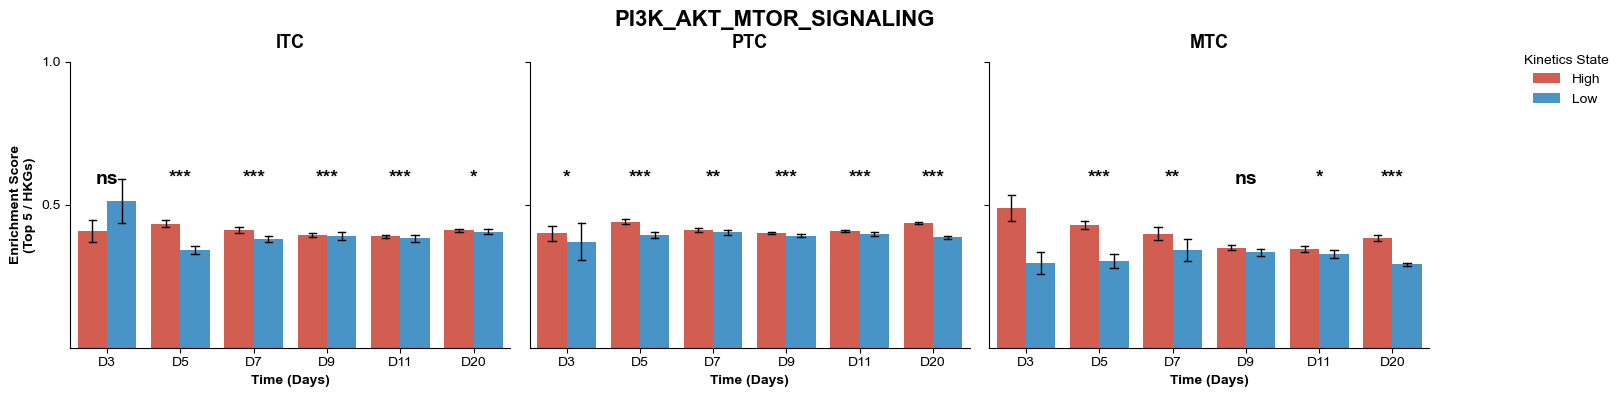

In [ ]:
# pathway 2
json_file = 'HALLMARK_PI3K_AKT_MTOR_SIGNALING.v2026.1.Mm.json'
pathway = "HALLMARK_PI3K_AKT_MTOR_SIGNALING"

adata_valid = calculate_pathway_score(
    adata=adata_valid, 
    json_path=json_file, 
    pathway_key=pathway, 
    score_name="PI3K_AKT_MTOR_SIGNALING_Score"
)

plot_pathway_enrichment(
    adata=adata_valid, 
    score_col="PI3K_AKT_MTOR_SIGNALING_Score", 
    target_cells=cells, 
    time_order=times, 
    output_pdf="HALLMARK_PI3K_AKT_MTOR_SIGNALING.pdf",
    plot_title="PI3K_AKT_MTOR_SIGNALING"
)

Pathway: HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION
Top 5 Core Driving Genes:
      Rank 1 : Vim 
      Rank 2 : Sat1 
      Rank 3 : Spp1 
      Rank 4 : Serpinh1 
      Rank 5 : Rhob 


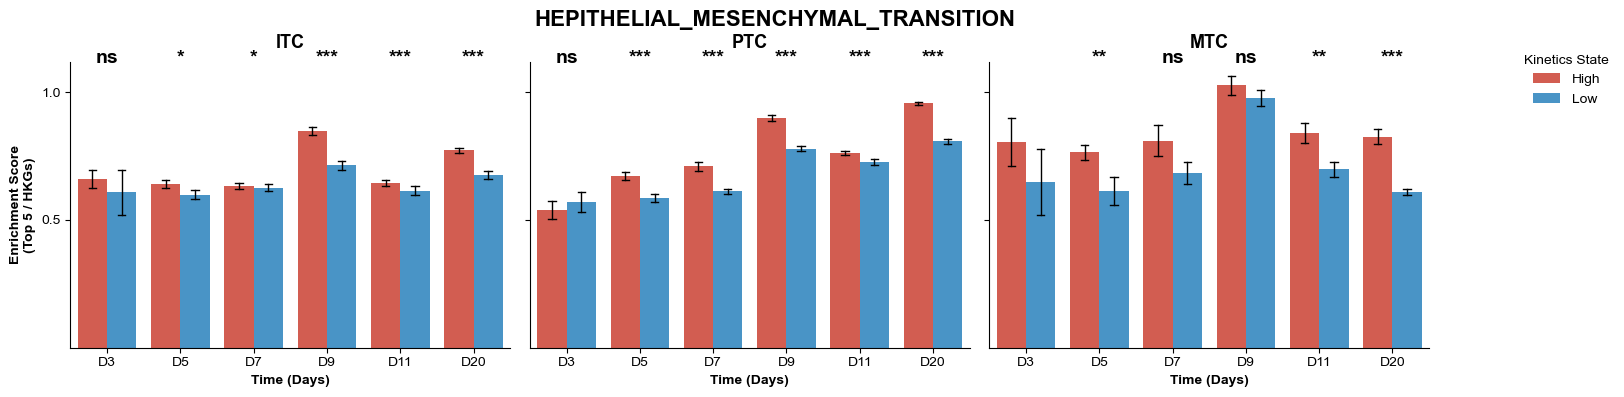

In [ ]:
# pathway 3
json_file = 'HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION.v2026.1.Mm.json'
pathway = "HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION"

adata_valid = calculate_pathway_score(
    adata=adata_valid, 
    json_path=json_file, 
    pathway_key=pathway, 
    score_name="EPITHELIAL_MESENCHYMAL_TRANSITION_Score"
)

plot_pathway_enrichment(
    adata=adata_valid, 
    score_col="EPITHELIAL_MESENCHYMAL_TRANSITION_Score", 
    target_cells=cells, 
    time_order=times, 
    output_pdf="HALLMARK_EPITHELIAL_MESENCHYMAL_TRANSITION.pdf",
    plot_title="HEPITHELIAL_MESENCHYMAL_TRANSITION"
)